
# Election Bloc Change Prediction Project  
## Notebook 05 — Delta Modeling and Added-Value Test

### Purpose

Notebook 03 established a demanding benchmark: the previous-election persistence baseline achieved the best validation result among the simple baselines.

This notebook now tests the revised research question directly:

> **Do demographic, socioeconomic, education, income and welfare features improve prediction of locality-level voting change beyond previous-election persistence?**

The target is the change in the four-bloc composition in centered log-ratio space:

\[
\Delta CLR = CLR(current) - CLR(previous)
\]

Predicted CLR changes are added to the previous-election CLR composition and transformed back into positive vote shares that sum to 100%.

### Experimental split

| Role | Transitions |
|---|---|
| Training | K21→K22 and K22→K23 |
| Validation/model selection | K23→K24 |
| Locked final test | K24→K25 |

The final-test targets remain untouched in this notebook.

### Comparable analysis sample

Annual locality profiles exist for only a subset of election localities. All model comparisons involving annual features are therefore performed on the **same validation localities with matched annual data**.

Persistence is reported twice:

1. On the full validation transition, for continuity with Notebook 03.
2. On the annual-data analysis sample, for a fair comparison with learned models.

### Candidate approaches

1. Previous-election persistence.
2. Global historical CLR swing.
3. Locality-type historical CLR swing.
4. Ridge regression using previous-election history only.
5. Ridge regression using socioeconomic features only.
6. Ridge regression using history plus annual feature levels.
7. Ridge regression using history, levels and annual changes.
8. Extra Trees using history, levels and annual changes.

### Main outputs

- `reports/tables/delta_model_comparison_validation.csv`
- `reports/tables/delta_model_comparison_by_bloc.csv`
- `reports/tables/delta_model_comparison_by_group.csv`
- `reports/tables/ridge_alpha_group_cv.csv`
- `reports/tables/modeling_sample_coverage.csv`
- `reports/tables/model_feature_filter_audit.csv`
- `data/processed/validation_predictions_best_delta_model.csv`
- `models/best_learned_delta_model.joblib`
- `reports/figures/delta_model_validation_comparison.png`
- `reports/summaries/selected_delta_model.json`
- `reports/summaries/notebook_05_summary.json`


## 1. Imports and repository setup

In [1]:

from pathlib import Path
import json
import os
import platform
import shutil
import subprocess
import sys
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 260)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 99

MODELED_BLOCS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
]

TRAIN_TRANSITIONS = [
    "K21_to_K22",
    "K22_to_K23",
]

VALIDATION_TRANSITION = "K23_to_K24"
FINAL_TEST_TRANSITION = "K24_to_K25"

TARGET_CLR_COLUMNS = [
    f"delta_clr_{bloc}"
    for bloc in MODELED_BLOCS
]

PREVIOUS_CLR_COLUMNS = [
    f"previous_clr_{bloc}"
    for bloc in MODELED_BLOCS
]

PREVIOUS_PCT_COLUMNS = [
    f"previous_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

CURRENT_PCT_COLUMNS = [
    f"current_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1


In [2]:

REPO_URL = (
    "https://github.com/IfatDav/"
    "Election_Bloc_Prediction_Project.git"
)

DEFAULT_REPO_DIR = Path(
    "/content/Election_Bloc_Prediction_Project"
)


def locate_repository():
    """Locate the repository or clone it in a fresh Colab runtime."""
    candidates = []

    explicit_root = os.getenv("ELECTION_PROJECT_ROOT")
    if explicit_root:
        candidates.append(
            Path(explicit_root).expanduser()
        )

    current = Path.cwd().resolve()
    candidates.extend(
        [current, *current.parents]
    )
    candidates.extend([
        DEFAULT_REPO_DIR,
        Path("/content/Election_Bloc_Change_Project"),
    ])

    checked = set()

    for candidate in candidates:
        candidate = candidate.resolve()

        if candidate in checked:
            continue

        checked.add(candidate)

        if (
            candidate / "data" / "raw"
        ).exists():
            return candidate

    if Path("/content").exists():
        if DEFAULT_REPO_DIR.exists():
            shutil.rmtree(
                DEFAULT_REPO_DIR
            )

        print("Repository not found locally.")
        print("Cloning the project repository...")

        result = subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(DEFAULT_REPO_DIR),
            ],
            text=True,
            capture_output=True,
        )

        if result.stdout:
            print(result.stdout)

        if result.returncode != 0:
            if result.stderr:
                print(result.stderr)

            raise RuntimeError(
                "Git clone failed. Review the Git output above."
            )

        return DEFAULT_REPO_DIR

    checked_text = "\n".join(
        f"- {path}"
        for path in checked
    )

    raise FileNotFoundError(
        "Could not locate the project repository.\n"
        f"Checked:\n{checked_text}"
    )


def synchronize_if_missing(
    repo_root,
    required_paths,
):
    """Pull the latest main branch when required files are missing."""
    missing = [
        path
        for path in required_paths
        if not path.exists()
    ]

    if not missing:
        return

    if not (
        repo_root / ".git"
    ).exists():
        return

    print("Some required files are missing locally.")
    print("Synchronizing with GitHub...")

    result = subprocess.run(
        [
            "git",
            "-C",
            str(repo_root),
            "pull",
            "--ff-only",
            "origin",
            "main",
        ],
        text=True,
        capture_output=True,
    )

    if result.stdout:
        print(result.stdout)

    if result.returncode != 0:
        if result.stderr:
            print(result.stderr)

        raise RuntimeError(
            "Git pull failed. Restart the runtime or resolve "
            "local repository conflicts."
        )


REPO_ROOT = locate_repository()

INTERIM_DIR = REPO_ROOT / "data" / "interim"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
REPORTS_DIR = REPO_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
SUMMARIES_DIR = REPORTS_DIR / "summaries"
MODELS_DIR = REPO_ROOT / "models"

for directory in [
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
    MODELS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

MODELING_FEATURES_PATH = (
    INTERIM_DIR
    / "modeling_transition_features.csv"
)

FEATURE_MANIFEST_PATH = (
    SUMMARIES_DIR
    / "feature_manifest.json"
)

NOTEBOOK_04_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_04_summary.json"
)

NOTEBOOK_03_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_03_summary.json"
)

synchronize_if_missing(
    REPO_ROOT,
    [
        MODELING_FEATURES_PATH,
        FEATURE_MANIFEST_PATH,
        NOTEBOOK_04_SUMMARY_PATH,
        NOTEBOOK_03_SUMMARY_PATH,
    ],
)

print("Repository root:", REPO_ROOT)
print("Modeling table:", MODELING_FEATURES_PATH)


Repository not found locally.
Cloning the project repository...
Repository root: /content/Election_Bloc_Prediction_Project
Modeling table: /content/Election_Bloc_Prediction_Project/data/interim/modeling_transition_features.csv


## 2. Load and validate previous notebook outputs

In [3]:

required_paths = [
    MODELING_FEATURES_PATH,
    FEATURE_MANIFEST_PATH,
    NOTEBOOK_04_SUMMARY_PATH,
    NOTEBOOK_03_SUMMARY_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Required files are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )

modeling_data = pd.read_csv(
    MODELING_FEATURES_PATH,
    dtype={
        "locality_symbol": "string",
    },
    low_memory=False,
)

with FEATURE_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:
    feature_manifest = json.load(file)

with NOTEBOOK_04_SUMMARY_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:
    notebook_04_summary = json.load(file)

with NOTEBOOK_03_SUMMARY_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:
    notebook_03_summary = json.load(file)

expected_rows = notebook_04_summary[
    "modeling_transition_rows"
]

if len(modeling_data) != expected_rows:
    raise ValueError(
        "Modeling-table row count differs from Notebook 04 "
        f"summary. Expected {expected_rows}, found "
        f"{len(modeling_data)}."
    )

duplicate_rows = int(
    modeling_data.duplicated(
        [
            "locality_symbol",
            "transition_id",
        ]
    ).sum()
)

if duplicate_rows:
    raise ValueError(
        f"Found {duplicate_rows} duplicated locality-transition rows."
    )

missing_targets = int(
    modeling_data[
        TARGET_CLR_COLUMNS
    ].isna().any(axis=1).sum()
)

if missing_targets:
    raise ValueError(
        f"Found {missing_targets} rows with missing CLR targets."
    )

print("Rows loaded:", len(modeling_data))
print(
    "Transitions:",
    modeling_data[
        "transition_id"
    ].value_counts().to_dict(),
)
print(
    "Annual feature count:",
    notebook_04_summary[
        "annual_feature_count"
    ],
)


Rows loaded: 4851
Transitions: {'K22_to_K23': 1214, 'K24_to_K25': 1213, 'K21_to_K22': 1212, 'K23_to_K24': 1212}
Annual feature count: 174



## 3. Define the comparable modeling sample

Annual profiles cover roughly 225 localities per transition, not all election localities.

The learned models are therefore trained and compared only on rows with both previous-year and current-year annual features.

No row is removed because of individual missing feature values at this stage. Missingness filtering and imputation are fitted from the training sample only.


In [4]:

modeling_data[
    "previous_log_valid_votes"
] = np.log1p(
    pd.to_numeric(
        modeling_data[
            "previous_valid_votes"
        ],
        errors="coerce",
    )
)

train_full = modeling_data.loc[
    modeling_data[
        "transition_id"
    ].isin(TRAIN_TRANSITIONS)
].copy()

validation_full = modeling_data.loc[
    modeling_data[
        "transition_id"
    ].eq(VALIDATION_TRANSITION)
].copy()

final_test_locked = modeling_data.loc[
    modeling_data[
        "transition_id"
    ].eq(FINAL_TEST_TRANSITION)
].copy()

train_data = train_full.loc[
    train_full[
        "has_complete_annual_pair"
    ].fillna(False)
].copy()

validation_data = validation_full.loc[
    validation_full[
        "has_complete_annual_pair"
    ].fillna(False)
].copy()

final_test_eligible_rows = int(
    final_test_locked[
        "has_complete_annual_pair"
    ].fillna(False).sum()
)

if train_data.empty:
    raise ValueError(
        "No training rows have complete annual feature pairs."
    )

if validation_data.empty:
    raise ValueError(
        "No validation rows have complete annual feature pairs."
    )

sample_coverage_rows = []

for split_name, data_full, data_eligible in [
    (
        "train",
        train_full,
        train_data,
    ),
    (
        "validation",
        validation_full,
        validation_data,
    ),
]:
    full_votes = pd.to_numeric(
        data_full[
            "current_valid_votes"
        ],
        errors="coerce",
    ).sum()

    eligible_votes = pd.to_numeric(
        data_eligible[
            "current_valid_votes"
        ],
        errors="coerce",
    ).sum()

    sample_coverage_rows.append({
        "split": split_name,
        "full_rows": len(data_full),
        "eligible_rows": len(
            data_eligible
        ),
        "eligible_row_coverage_pct": (
            len(data_eligible)
            / len(data_full)
            * 100
        ),
        "full_current_valid_votes": (
            float(full_votes)
        ),
        "eligible_current_valid_votes": (
            float(eligible_votes)
        ),
        "eligible_vote_coverage_pct": (
            float(
                eligible_votes
                / full_votes
                * 100
            )
            if full_votes > 0
            else np.nan
        ),
    })

sample_coverage_rows.append({
    "split": "final_test_locked",
    "full_rows": len(
        final_test_locked
    ),
    "eligible_rows": (
        final_test_eligible_rows
    ),
    "eligible_row_coverage_pct": (
        final_test_eligible_rows
        / len(final_test_locked)
        * 100
    ),
    "full_current_valid_votes": np.nan,
    "eligible_current_valid_votes": np.nan,
    "eligible_vote_coverage_pct": np.nan,
})

modeling_sample_coverage = (
    pd.DataFrame(
        sample_coverage_rows
    )
)

modeling_sample_coverage


,split,full_rows,eligible_rows,eligible_row_coverage_pct,full_current_valid_votes,eligible_current_valid_votes,eligible_vote_coverage_pct
0,train,2426,449,18.507832,8746524.0,7512994.0,85.896912
1,validation,1212,224,18.481848,4409811.0,3540457.0,80.285912
2,final_test_locked,1213,224,18.466612,NaN,NaN,NaN



The final-test row count and annual-feature eligibility are recorded only as metadata. Its outcomes are not evaluated here.


## 4. Construct candidate feature sets

In [5]:

manifest_current_features = [
    column
    for column in feature_manifest[
        "current_annual_feature_columns"
    ]
    if column in modeling_data.columns
]

manifest_delta_features = [
    column
    for column in feature_manifest[
        "delta_annual_feature_columns"
    ]
    if column in modeling_data.columns
]

history_numeric_features = [
    *PREVIOUS_CLR_COLUMNS,
    "previous_turnout_pct",
    "previous_log_valid_votes",
]

categorical_feature = "locality_type"

RAW_FEATURE_SETS = {
    "Ridge — history only": [
        *history_numeric_features,
    ],
    "Ridge — socioeconomic only": [
        categorical_feature,
        *manifest_current_features,
        *manifest_delta_features,
    ],
    "Ridge — history + levels": [
        *history_numeric_features,
        categorical_feature,
        *manifest_current_features,
    ],
    "Ridge — history + levels + change": [
        *history_numeric_features,
        categorical_feature,
        *manifest_current_features,
        *manifest_delta_features,
    ],
}

EXTRA_TREES_FEATURE_SET = [
    *history_numeric_features,
    categorical_feature,
    *manifest_current_features,
    *manifest_delta_features,
]

print(
    "Current annual features found:",
    len(manifest_current_features),
)
print(
    "Delta annual features found:",
    len(manifest_delta_features),
)


Current annual features found: 174
Delta annual features found: 174



## 5. Training-only feature filtering

For each candidate set:

1. Categorical variables are retained when they contain more than one training category.
2. Numeric variables with more than 30% missingness in the eligible training sample are removed.
3. Fully constant numeric variables are removed.
4. The remaining missing values are imputed with training medians inside the model pipeline.

This corrects an important distinction:

- overall missingness across all 4,851 election-transition rows is high because most localities have no annual CBS profile;
- model-feature missingness must be assessed **inside the eligible annual-data training sample**.


In [6]:

TRAINING_MISSINGNESS_THRESHOLD = 0.30


def filter_features_from_training(
    data,
    feature_columns,
    model_name,
):
    kept = []
    audit_rows = []

    for column in feature_columns:
        if column not in data.columns:
            audit_rows.append({
                "model": model_name,
                "feature": column,
                "feature_type": "unknown",
                "training_missing_pct": np.nan,
                "training_unique_non_missing": 0,
                "kept": False,
                "reason": "column_missing",
            })
            continue

        if column == categorical_feature:
            values = (
                data[column]
                .astype("string")
            )

            unique_count = int(
                values.nunique(
                    dropna=True
                )
            )

            keep = unique_count > 1

            audit_rows.append({
                "model": model_name,
                "feature": column,
                "feature_type": "categorical",
                "training_missing_pct": float(
                    values.isna().mean()
                    * 100
                ),
                "training_unique_non_missing": (
                    unique_count
                ),
                "kept": keep,
                "reason": (
                    "kept"
                    if keep
                    else "constant_or_empty"
                ),
            })

            if keep:
                kept.append(column)

            continue

        numeric_values = pd.to_numeric(
            data[column],
            errors="coerce",
        )

        missing_rate = float(
            numeric_values.isna().mean()
        )

        unique_count = int(
            numeric_values.nunique(
                dropna=True
            )
        )

        if missing_rate > (
            TRAINING_MISSINGNESS_THRESHOLD
        ):
            keep = False
            reason = "missingness_above_threshold"
        elif unique_count <= 1:
            keep = False
            reason = "constant_or_empty"
        else:
            keep = True
            reason = "kept"

        audit_rows.append({
            "model": model_name,
            "feature": column,
            "feature_type": "numeric",
            "training_missing_pct": (
                missing_rate * 100
            ),
            "training_unique_non_missing": (
                unique_count
            ),
            "kept": keep,
            "reason": reason,
        })

        if keep:
            kept.append(column)

    if not kept:
        raise ValueError(
            f"No features survived filtering for {model_name}."
        )

    return (
        kept,
        pd.DataFrame(
            audit_rows
        ),
    )


FILTERED_FEATURE_SETS = {}
feature_filter_audits = []

for model_name, raw_features in (
    RAW_FEATURE_SETS.items()
):
    (
        filtered_features,
        filter_audit,
    ) = filter_features_from_training(
        train_data,
        raw_features,
        model_name,
    )

    FILTERED_FEATURE_SETS[
        model_name
    ] = filtered_features

    feature_filter_audits.append(
        filter_audit
    )

(
    filtered_extra_trees_features,
    extra_trees_filter_audit,
) = filter_features_from_training(
    train_data,
    EXTRA_TREES_FEATURE_SET,
    "Extra Trees — history + levels + change",
)

feature_filter_audits.append(
    extra_trees_filter_audit
)

model_feature_filter_audit = pd.concat(
    feature_filter_audits,
    ignore_index=True,
)

feature_filter_summary = (
    model_feature_filter_audit.groupby(
        [
            "model",
            "kept",
            "reason",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "features",
        }
    )
)

feature_filter_summary


,model,kept,reason,features
0,Extra Trees — history + levels + change,False,constant_or_empty,1
1,Extra Trees — history + levels + change,False,missingness_above_threshold,115
2,Extra Trees — history + levels + change,True,kept,239
3,Ridge — history + levels,False,missingness_above_threshold,56
4,Ridge — history + levels,True,kept,125
5,Ridge — history + levels + change,False,constant_or_empty,1
6,Ridge — history + levels + change,False,missingness_above_threshold,115
7,Ridge — history + levels + change,True,kept,239
8,Ridge — history only,True,kept,6
9,Ridge — socioeconomic only,False,constant_or_empty,1


## 6. Modeling and compositional evaluation utilities

In [7]:

def make_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def prepare_feature_frame(
    data,
    feature_columns,
):
    output = data[
        feature_columns
    ].copy()

    for column in feature_columns:
        if column == categorical_feature:
            output[column] = (
                output[column]
                .astype("string")
                .fillna("Unknown")
                .astype(str)
            )
        else:
            output[column] = pd.to_numeric(
                output[column],
                errors="coerce",
            ).astype("float64")

    return output


def build_preprocessor(
    feature_columns,
    scale_numeric,
):
    categorical_columns = [
        column
        for column in feature_columns
        if column == categorical_feature
    ]

    numeric_columns = [
        column
        for column in feature_columns
        if column not in categorical_columns
    ]

    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
    ]

    if scale_numeric:
        numeric_steps.append(
            (
                "scaler",
                StandardScaler(),
            )
        )

    transformers = []

    if numeric_columns:
        transformers.append(
            (
                "numeric",
                Pipeline(
                    numeric_steps
                ),
                numeric_columns,
            )
        )

    if categorical_columns:
        transformers.append(
            (
                "categorical",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy=(
                                "most_frequent"
                            )
                        ),
                    ),
                    (
                        "one_hot",
                        make_one_hot_encoder(),
                    ),
                ]),
                categorical_columns,
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )

    return preprocessor


def build_ridge_pipeline(
    feature_columns,
    alpha,
):
    return Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                feature_columns,
                scale_numeric=True,
            ),
        ),
        (
            "model",
            Ridge(
                alpha=alpha,
            ),
        ),
    ])


def build_extra_trees_pipeline(
    feature_columns,
):
    return Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                feature_columns,
                scale_numeric=False,
            ),
        ),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=350,
                min_samples_leaf=3,
                max_features=0.6,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ])


def center_clr_rows(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return (
        values
        - values.mean(
            axis=1,
            keepdims=True,
        )
    )


def inverse_clr(clr_values):
    clr_values = np.asarray(
        clr_values,
        dtype=float,
    )

    shifted = (
        clr_values
        - clr_values.max(
            axis=1,
            keepdims=True,
        )
    )

    exp_values = np.exp(
        shifted
    )

    return (
        exp_values
        / exp_values.sum(
            axis=1,
            keepdims=True,
        )
        * 100
    )


def delta_clr_to_composition(
    data,
    predicted_delta_clr,
):
    predicted_delta_clr = (
        center_clr_rows(
            predicted_delta_clr
        )
    )

    previous_clr = data[
        PREVIOUS_CLR_COLUMNS
    ].to_numpy(dtype=float)

    predicted_current_clr = (
        previous_clr
        + predicted_delta_clr
    )

    return inverse_clr(
        predicted_current_clr
    )


def predict_model_composition(
    pipeline,
    data,
    feature_columns,
):
    features = prepare_feature_frame(
        data,
        feature_columns,
    )

    predicted_delta_clr = (
        pipeline.predict(
            features
        )
    )

    return delta_clr_to_composition(
        data,
        predicted_delta_clr,
    )


def safe_r2(
    y_true,
    y_pred,
):
    if len(y_true) < 2:
        return np.nan

    if np.nanstd(y_true) == 0:
        return np.nan

    return float(
        r2_score(
            y_true,
            y_pred,
        )
    )


def evaluate_composition(
    data,
    predictions,
    model_name,
):
    y_true = data[
        CURRENT_PCT_COLUMNS
    ].to_numpy(dtype=float)

    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    if predictions.shape != y_true.shape:
        raise ValueError(
            f"{model_name}: prediction shape "
            f"{predictions.shape} does not match "
            f"target shape {y_true.shape}."
        )

    maximum_sum_error = float(
        np.abs(
            predictions.sum(axis=1)
            - 100
        ).max()
    )

    if maximum_sum_error > 1e-6:
        raise ValueError(
            f"{model_name}: predictions do not sum to 100."
        )

    absolute_errors = np.abs(
        y_true
        - predictions
    )

    row_mae = absolute_errors.mean(
        axis=1
    )

    weights = pd.to_numeric(
        data[
            "current_valid_votes"
        ],
        errors="coerce",
    ).to_numpy(dtype=float)

    weighted_mae = float(
        np.average(
            row_mae,
            weights=weights,
        )
    )

    r2_values = [
        safe_r2(
            y_true[:, index],
            predictions[:, index],
        )
        for index in range(
            len(MODELED_BLOCS)
        )
    ]

    overall_row = {
        "model": model_name,
        "rows": len(data),
        "mae": float(
            absolute_errors.mean()
        ),
        "median_row_mae": float(
            np.median(row_mae)
        ),
        "weighted_mae": weighted_mae,
        "macro_r2": float(
            np.nanmean(r2_values)
        ),
        "maximum_prediction_sum_error": (
            maximum_sum_error
        ),
    }

    bloc_rows = []

    for index, bloc in enumerate(
        MODELED_BLOCS
    ):
        bloc_rows.append({
            "model": model_name,
            "bloc": bloc,
            "rows": len(data),
            "mae": float(
                absolute_errors[
                    :,
                    index,
                ].mean()
            ),
            "median_absolute_error": float(
                np.median(
                    absolute_errors[
                        :,
                        index,
                    ]
                )
            ),
            "r2": r2_values[
                index
            ],
        })

    return (
        overall_row,
        bloc_rows,
    )


def evaluate_by_group(
    data,
    predictions,
    model_name,
):
    rows = []

    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    group_values = (
        data[
            "analysis_group"
        ]
        .fillna("Unknown")
        .unique()
        .tolist()
    )

    for group_value in sorted(
        group_values
    ):
        mask = (
            data[
                "analysis_group"
            ]
            .fillna("Unknown")
            .eq(group_value)
            .to_numpy()
        )

        group_data = data.loc[
            mask
        ]

        group_predictions = (
            predictions[mask]
        )

        overall_row, _ = (
            evaluate_composition(
                group_data,
                group_predictions,
                model_name,
            )
        )

        rows.append({
            "model": model_name,
            "analysis_group": (
                group_value
            ),
            **{
                key: value
                for key, value
                in overall_row.items()
                if key != "model"
            },
        })

    return rows


## 7. Fair-comparison baselines

In [8]:

BASELINE_PREDICTIONS = {}

# Persistence: predicted current shares equal previous shares.
BASELINE_PREDICTIONS[
    "Previous-election persistence"
] = validation_data[
    PREVIOUS_PCT_COLUMNS
].to_numpy(dtype=float)


# Global historical CLR swing.
global_mean_delta_clr = (
    train_data[
        TARGET_CLR_COLUMNS
    ].mean().to_numpy(dtype=float)
)

global_delta_matrix = np.tile(
    global_mean_delta_clr,
    (
        len(validation_data),
        1,
    ),
)

BASELINE_PREDICTIONS[
    "Global historical CLR swing"
] = delta_clr_to_composition(
    validation_data,
    global_delta_matrix,
)


# Locality-type historical CLR swing.
type_delta_lookup = (
    train_data.groupby(
        "locality_type",
        dropna=False,
        observed=False,
    )[TARGET_CLR_COLUMNS]
    .mean()
)

type_delta_rows = []

for locality_type in (
    validation_data[
        "locality_type"
    ].fillna("Unknown")
):
    if locality_type in (
        type_delta_lookup.index
    ):
        type_delta_rows.append(
            type_delta_lookup.loc[
                locality_type
            ].to_numpy(dtype=float)
        )
    else:
        type_delta_rows.append(
            global_mean_delta_clr
        )

type_delta_matrix = np.vstack(
    type_delta_rows
)

BASELINE_PREDICTIONS[
    "Locality-type historical CLR swing"
] = delta_clr_to_composition(
    validation_data,
    type_delta_matrix,
)


# Full-validation persistence context from the complete K23→K24 transition.
full_validation_persistence = (
    validation_full[
        PREVIOUS_PCT_COLUMNS
    ].to_numpy(dtype=float)
)

(
    full_persistence_metrics,
    _,
) = evaluate_composition(
    validation_full,
    full_validation_persistence,
    "Previous-election persistence — full validation",
)

pd.DataFrame([
    full_persistence_metrics
])


,model,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error
0,Previous-election persistence — full validation,1212,3.082348,2.430337,2.398171,0.946765,2.842171e-14



## 8. Select Ridge regularization with grouped cross-validation

Ridge alpha is selected using GroupKFold on the training transitions, with all rows from the same locality kept in the same fold.

This avoids choosing regularization strength from a split where one election from a locality is in training and another election from the same locality is in validation.

The cross-validation score is vote-share MAE after:

1. predicting CLR change,
2. adding it to previous-election CLR,
3. converting back to a four-bloc composition.


In [9]:

RIDGE_ALPHA_GRID = [
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
]

group_count = int(
    train_data[
        "locality_symbol"
    ].nunique()
)

n_splits = min(
    5,
    group_count,
)

if n_splits < 2:
    raise ValueError(
        "At least two locality groups are required for grouped CV."
    )

group_cv = GroupKFold(
    n_splits=n_splits
)

ridge_cv_rows = []
selected_ridge_alphas = {}

for model_name, feature_columns in (
    FILTERED_FEATURE_SETS.items()
):
    X_all = prepare_feature_frame(
        train_data,
        feature_columns,
    )

    y_all = train_data[
        TARGET_CLR_COLUMNS
    ].to_numpy(dtype=float)

    groups = train_data[
        "locality_symbol"
    ].astype(str).to_numpy()

    alpha_scores = []

    for alpha in RIDGE_ALPHA_GRID:
        fold_scores = []

        for fold_number, (
            train_indices,
            validation_indices,
        ) in enumerate(
            group_cv.split(
                X_all,
                y_all,
                groups,
            ),
            start=1,
        ):
            fold_pipeline = (
                build_ridge_pipeline(
                    feature_columns,
                    alpha,
                )
            )

            fold_pipeline.fit(
                X_all.iloc[
                    train_indices
                ],
                y_all[
                    train_indices
                ],
            )

            fold_data = train_data.iloc[
                validation_indices
            ]

            fold_predictions = (
                predict_model_composition(
                    fold_pipeline,
                    fold_data,
                    feature_columns,
                )
            )

            fold_metrics, _ = (
                evaluate_composition(
                    fold_data,
                    fold_predictions,
                    model_name,
                )
            )

            fold_score = float(
                fold_metrics["mae"]
            )

            fold_scores.append(
                fold_score
            )

            ridge_cv_rows.append({
                "model": model_name,
                "alpha": alpha,
                "fold": fold_number,
                "fold_rows": len(
                    validation_indices
                ),
                "fold_mae": fold_score,
            })

        alpha_scores.append({
            "alpha": alpha,
            "mean_cv_mae": float(
                np.mean(
                    fold_scores
                )
            ),
            "std_cv_mae": float(
                np.std(
                    fold_scores
                )
            ),
        })

    alpha_score_table = (
        pd.DataFrame(
            alpha_scores
        )
        .sort_values(
            [
                "mean_cv_mae",
                "alpha",
            ]
        )
        .reset_index(drop=True)
    )

    selected_alpha = float(
        alpha_score_table.iloc[
            0
        ]["alpha"]
    )

    selected_ridge_alphas[
        model_name
    ] = selected_alpha

    print(
        model_name,
        "selected alpha:",
        selected_alpha,
        "CV MAE:",
        round(
            float(
                alpha_score_table.iloc[
                    0
                ]["mean_cv_mae"]
            ),
            4,
        ),
    )

ridge_alpha_group_cv = pd.DataFrame(
    ridge_cv_rows
)

ridge_alpha_summary = (
    ridge_alpha_group_cv.groupby(
        [
            "model",
            "alpha",
        ],
        as_index=False,
    )["fold_mae"]
    .agg(
        mean_cv_mae="mean",
        std_cv_mae="std",
    )
)

ridge_alpha_summary


Ridge — history only selected alpha: 1000.0 CV MAE: 2.5122
Ridge — socioeconomic only selected alpha: 1000.0 CV MAE: 1.9737
Ridge — history + levels selected alpha: 1000.0 CV MAE: 1.8605
Ridge — history + levels + change selected alpha: 1000.0 CV MAE: 1.946


,model,alpha,mean_cv_mae,std_cv_mae
0,Ridge — history + levels,0.1,5.378511,1.209171
1,Ridge — history + levels,1.0,4.484436,1.059120
2,Ridge — history + levels,10.0,3.533855,0.667231
3,Ridge — history + levels,100.0,2.540748,0.281392
4,Ridge — history + levels,1000.0,1.860518,0.227032
5,Ridge — history + levels + change,0.1,9.551064,2.730662
6,Ridge — history + levels + change,1.0,7.103692,2.340349
7,Ridge — history + levels + change,10.0,4.741302,1.254700
8,Ridge — history + levels + change,100.0,2.943551,0.436432
9,Ridge — history + levels + change,1000.0,1.946026,0.163999


## 9. Fit candidate models and predict validation

In [10]:

MODEL_PREDICTIONS = dict(
    BASELINE_PREDICTIONS
)

FITTED_MODELS = {}
MODEL_FEATURE_COLUMNS = {}
MODEL_TRAINING_SECONDS = {}

y_train = train_data[
    TARGET_CLR_COLUMNS
].to_numpy(dtype=float)

for model_name, feature_columns in (
    FILTERED_FEATURE_SETS.items()
):
    alpha = selected_ridge_alphas[
        model_name
    ]

    pipeline = build_ridge_pipeline(
        feature_columns,
        alpha,
    )

    X_train = prepare_feature_frame(
        train_data,
        feature_columns,
    )

    start_time = time.perf_counter()

    pipeline.fit(
        X_train,
        y_train,
    )

    training_seconds = (
        time.perf_counter()
        - start_time
    )

    predictions = (
        predict_model_composition(
            pipeline,
            validation_data,
            feature_columns,
        )
    )

    MODEL_PREDICTIONS[
        model_name
    ] = predictions

    FITTED_MODELS[
        model_name
    ] = pipeline

    MODEL_FEATURE_COLUMNS[
        model_name
    ] = feature_columns

    MODEL_TRAINING_SECONDS[
        model_name
    ] = training_seconds


extra_trees_name = (
    "Extra Trees — history + levels + change"
)

extra_trees_pipeline = (
    build_extra_trees_pipeline(
        filtered_extra_trees_features
    )
)

X_train_extra = prepare_feature_frame(
    train_data,
    filtered_extra_trees_features,
)

start_time = time.perf_counter()

extra_trees_pipeline.fit(
    X_train_extra,
    y_train,
)

MODEL_TRAINING_SECONDS[
    extra_trees_name
] = (
    time.perf_counter()
    - start_time
)

extra_trees_predictions = (
    predict_model_composition(
        extra_trees_pipeline,
        validation_data,
        filtered_extra_trees_features,
    )
)

MODEL_PREDICTIONS[
    extra_trees_name
] = (
    extra_trees_predictions
)

FITTED_MODELS[
    extra_trees_name
] = (
    extra_trees_pipeline
)

MODEL_FEATURE_COLUMNS[
    extra_trees_name
] = (
    filtered_extra_trees_features
)

print(
    "Candidate predictions created:",
    len(MODEL_PREDICTIONS),
)


Candidate predictions created: 8


## 10. Validation comparison

In [11]:

overall_rows = []
bloc_rows = []
group_rows = []

for model_name, predictions in (
    MODEL_PREDICTIONS.items()
):
    (
        overall_row,
        model_bloc_rows,
    ) = evaluate_composition(
        validation_data,
        predictions,
        model_name,
    )

    overall_row[
        "training_seconds"
    ] = MODEL_TRAINING_SECONDS.get(
        model_name,
        0.0,
    )

    overall_row[
        "feature_count_before_encoding"
    ] = len(
        MODEL_FEATURE_COLUMNS.get(
            model_name,
            [],
        )
    )

    overall_rows.append(
        overall_row
    )

    bloc_rows.extend(
        model_bloc_rows
    )

    group_rows.extend(
        evaluate_by_group(
            validation_data,
            predictions,
            model_name,
        )
    )

delta_model_comparison = (
    pd.DataFrame(
        overall_rows
    )
    .sort_values(
        [
            "mae",
            "weighted_mae",
        ]
    )
    .reset_index(drop=True)
)

delta_model_comparison_by_bloc = (
    pd.DataFrame(
        bloc_rows
    )
    .sort_values(
        [
            "bloc",
            "mae",
        ]
    )
    .reset_index(drop=True)
)

delta_model_comparison_by_group = (
    pd.DataFrame(
        group_rows
    )
    .sort_values(
        [
            "analysis_group",
            "mae",
        ]
    )
    .reset_index(drop=True)
)

persistence_mae = float(
    delta_model_comparison.loc[
        delta_model_comparison[
            "model"
        ].eq(
            "Previous-election persistence"
        ),
        "mae",
    ].iloc[0]
)

delta_model_comparison[
    "absolute_mae_improvement_vs_persistence"
] = (
    persistence_mae
    - delta_model_comparison[
        "mae"
    ]
)

delta_model_comparison[
    "relative_mae_improvement_vs_persistence_pct"
] = (
    delta_model_comparison[
        "absolute_mae_improvement_vs_persistence"
    ]
    / persistence_mae
    * 100
)

delta_model_comparison


,model,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error,training_seconds,feature_count_before_encoding,absolute_mae_improvement_vs_persistence,relative_mae_improvement_vs_persistence_pct
0,Previous-election persistence,224,3.254847,2.499673,2.353855,0.959238,2.842171e-14,0.000000,0,0.000000,0.000000
1,Ridge — history + levels,224,3.447612,1.838861,1.845152,0.951323,2.842171e-14,0.042670,125,-0.192765,-5.922398
2,Ridge — history only,224,4.003034,3.123246,3.157561,0.946975,2.842171e-14,0.015279,6,-0.748187,-22.986871
3,Global historical CLR swing,224,4.091588,3.088965,3.332041,0.944557,2.842171e-14,0.000000,0,-0.836742,-25.707557
4,Locality-type historical CLR swing,224,4.620182,3.573286,3.691861,0.932583,2.842171e-14,0.000000,0,-1.365335,-41.947754
5,Extra Trees — history + levels + change,224,4.639256,3.796456,3.725363,0.930851,2.842171e-14,4.095827,239,-1.384409,-42.533773
6,Ridge — history + levels + change,224,4.705567,4.103260,4.452265,0.927229,2.842171e-14,0.139064,239,-1.450720,-44.571077
7,Ridge — socioeconomic only,224,5.000700,4.183622,4.730387,0.917838,2.842171e-14,0.070287,233,-1.745854,-53.638594



A positive improvement value means the candidate beats persistence on the comparable annual-data validation sample. A negative value means it performs worse.


In [12]:

delta_model_comparison_by_bloc


,model,bloc,rows,mae,median_absolute_error,r2
0,Previous-election persistence,Arab,224,2.450316,0.348156,0.985415
1,Ridge — history + levels + change,Arab,224,4.020237,0.449012,0.960784
2,Ridge — history only,Arab,224,4.073503,0.875537,0.964779
3,Global historical CLR swing,Arab,224,4.333820,0.932982,0.960230
4,Extra Trees — history + levels + change,Arab,224,4.381008,0.545430,0.956669
5,Ridge — socioeconomic only,Arab,224,4.565910,0.550731,0.952324
6,Ridge — history + levels,Arab,224,4.847926,0.752789,0.944621
7,Locality-type historical CLR swing,Arab,224,4.918171,0.796698,0.947093
8,Ridge — history + levels,Center_Left,224,3.168103,1.561316,0.955527
9,Ridge — history only,Center_Left,224,3.793254,2.846110,0.952380


In [13]:

delta_model_comparison_by_group


,model,analysis_group,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error
0,Previous-election persistence,Arab/Non-Jewish,81,4.798793,3.464907,3.568429,0.782006,2.842171e-14
1,Ridge — history only,Arab/Non-Jewish,81,5.730238,3.852857,4.236971,0.742015,1.421085e-14
2,Ridge — history + levels + change,Arab/Non-Jewish,81,5.888754,3.747696,4.342140,0.707129,2.842171e-14
3,Global historical CLR swing,Arab/Non-Jewish,81,5.908201,4.100799,4.571114,0.750592,2.842171e-14
4,Ridge — socioeconomic only,Arab/Non-Jewish,81,6.305182,4.151541,4.771045,0.699646,2.842171e-14
5,Extra Trees — history + levels + change,Arab/Non-Jewish,81,6.319626,4.185333,4.870773,0.713055,2.842171e-14
6,Ridge — history + levels,Arab/Non-Jewish,81,6.587343,4.212548,5.012040,0.681148,1.421085e-14
7,Locality-type historical CLR swing,Arab/Non-Jewish,81,6.636223,4.362266,5.180998,0.701762,2.842171e-14
8,Ridge — history + levels,Non-Arab,143,1.669162,1.388022,1.482552,0.888608,2.842171e-14
9,Previous-election persistence,Non-Arab,143,2.380304,2.284845,2.214790,0.941635,2.842171e-14


## 11. Select the best learned model and operational recommendation

In [14]:

learned_model_names = list(
    FITTED_MODELS.keys()
)

best_learned_row = (
    delta_model_comparison.loc[
        delta_model_comparison[
            "model"
        ].isin(
            learned_model_names
        )
    ]
    .sort_values(
        [
            "mae",
            "weighted_mae",
        ]
    )
    .iloc[0]
)

best_learned_model_name = str(
    best_learned_row[
        "model"
    ]
)

best_learned_mae = float(
    best_learned_row[
        "mae"
    ]
)

learned_improvement = (
    persistence_mae
    - best_learned_mae
)

learned_relative_improvement = (
    learned_improvement
    / persistence_mae
    * 100
)

if best_learned_mae < persistence_mae:
    operational_recommendation = (
        best_learned_model_name
    )
    recommendation_reason = (
        "The best learned model improves validation MAE "
        "relative to persistence on the comparable sample."
    )
else:
    operational_recommendation = (
        "Previous-election persistence"
    )
    recommendation_reason = (
        "No learned model improves validation MAE "
        "relative to persistence on the comparable sample."
    )

selection_summary = pd.DataFrame([
    {
        "metric": "Full-validation persistence MAE",
        "value": float(
            full_persistence_metrics[
                "mae"
            ]
        ),
    },
    {
        "metric": (
            "Comparable-sample persistence MAE"
        ),
        "value": persistence_mae,
    },
    {
        "metric": "Best learned model",
        "value": best_learned_model_name,
    },
    {
        "metric": "Best learned model MAE",
        "value": best_learned_mae,
    },
    {
        "metric": (
            "Absolute MAE improvement vs persistence"
        ),
        "value": learned_improvement,
    },
    {
        "metric": (
            "Relative MAE improvement vs persistence (%)"
        ),
        "value": learned_relative_improvement,
    },
    {
        "metric": "Operational recommendation",
        "value": operational_recommendation,
    },
])

selection_summary


,metric,value
0,Full-validation persistence MAE,3.082348
1,Comparable-sample persistence MAE,3.254847
2,Best learned model,Ridge — history + levels
3,Best learned model MAE,3.447612
4,Absolute MAE improvement vs persistence,-0.192765
5,Relative MAE improvement vs persistence (%),-5.922398
6,Operational recommendation,Previous-election persistence



The best learned model is saved even when persistence remains the operational recommendation. This allows later notebooks to:

- test unseen-locality generalization,
- examine feature importance and partial dependence,
- inspect where the learned model adds or loses value,
- evaluate both approaches once on the locked final test.


## 12. Validation prediction table

In [15]:

best_learned_predictions = (
    MODEL_PREDICTIONS[
        best_learned_model_name
    ]
)

persistence_predictions = (
    MODEL_PREDICTIONS[
        "Previous-election persistence"
    ]
)

validation_predictions = (
    validation_data[
        [
            "locality_symbol",
            "locality_name",
            "transition_id",
            "locality_type",
            "analysis_group",
            "previous_valid_votes",
            "current_valid_votes",
            *PREVIOUS_PCT_COLUMNS,
            *CURRENT_PCT_COLUMNS,
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

for index, bloc in enumerate(
    MODELED_BLOCS
):
    validation_predictions[
        f"persistence_predicted_{bloc}_pct"
    ] = persistence_predictions[
        :,
        index,
    ]

    validation_predictions[
        f"model_predicted_{bloc}_pct"
    ] = best_learned_predictions[
        :,
        index,
    ]

    validation_predictions[
        f"persistence_absolute_error_{bloc}_pct"
    ] = np.abs(
        validation_predictions[
            f"current_{bloc}_pct"
        ]
        - validation_predictions[
            f"persistence_predicted_{bloc}_pct"
        ]
    )

    validation_predictions[
        f"model_absolute_error_{bloc}_pct"
    ] = np.abs(
        validation_predictions[
            f"current_{bloc}_pct"
        ]
        - validation_predictions[
            f"model_predicted_{bloc}_pct"
        ]
    )

validation_predictions[
    "persistence_mean_absolute_error"
] = validation_predictions[
    [
        f"persistence_absolute_error_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ]
].mean(axis=1)

validation_predictions[
    "model_mean_absolute_error"
] = validation_predictions[
    [
        f"model_absolute_error_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ]
].mean(axis=1)

validation_predictions[
    "model_improvement_vs_persistence"
] = (
    validation_predictions[
        "persistence_mean_absolute_error"
    ]
    - validation_predictions[
        "model_mean_absolute_error"
    ]
)

validation_predictions[
    "model_predicted_total"
] = validation_predictions[
    [
        f"model_predicted_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ]
].sum(axis=1)

validation_predictions[
    [
        "locality_name",
        "analysis_group",
        "persistence_mean_absolute_error",
        "model_mean_absolute_error",
        "model_improvement_vs_persistence",
    ]
].sort_values(
    "model_improvement_vs_persistence",
    ascending=False,
).head(20)


,locality_name,analysis_group,persistence_mean_absolute_error,model_mean_absolute_error,model_improvement_vs_persistence
174,אורנית,Non-Arab,3.608141,0.287561,3.320580
147,גדרה,Non-Arab,3.550438,0.559110,2.991328
136,שוהם,Non-Arab,2.980790,0.385004,2.595786
98,עומר,Non-Arab,3.693604,1.119107,2.574496
164,בית אל,Non-Arab,3.504163,1.021067,2.483096
129,להבים,Non-Arab,4.150207,1.678896,2.471311
175,הר אדר,Non-Arab,2.942312,0.574997,2.367316
113,קרית מלאכי,Non-Arab,4.336762,1.997129,2.339634
38,פרדסיה,Non-Arab,3.005404,0.786020,2.219384
45,בית דגן,Non-Arab,2.591160,0.395455,2.195705


## 13. Visual comparison

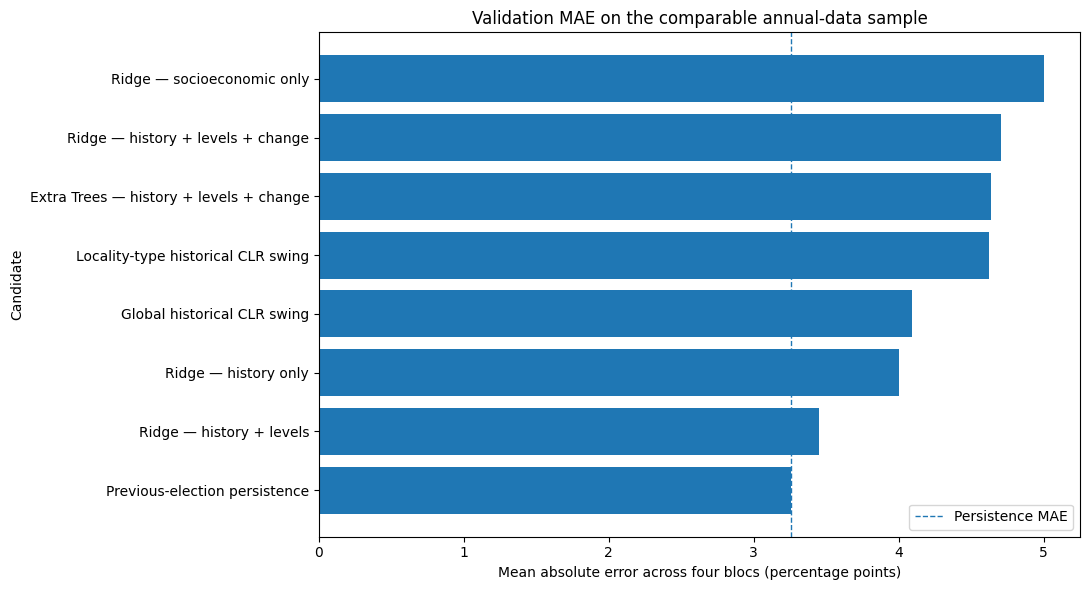

Figure saved to: /content/Election_Bloc_Prediction_Project/reports/figures/delta_model_validation_comparison.png


In [16]:

figure, axis = plt.subplots(
    figsize=(11, 6),
)

plot_data = (
    delta_model_comparison
    .sort_values(
        "mae",
        ascending=True,
    )
)

axis.barh(
    plot_data[
        "model"
    ],
    plot_data[
        "mae"
    ],
)

axis.axvline(
    persistence_mae,
    linestyle="--",
    linewidth=1,
    label="Persistence MAE",
)

axis.set_title(
    "Validation MAE on the comparable annual-data sample"
)

axis.set_xlabel(
    "Mean absolute error across four blocs "
    "(percentage points)"
)

axis.set_ylabel("Candidate")
axis.legend()

plt.tight_layout()

MODEL_COMPARISON_FIGURE_PATH = (
    FIGURES_DIR
    / "delta_model_validation_comparison.png"
)

plt.savefig(
    MODEL_COMPARISON_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    MODEL_COMPARISON_FIGURE_PATH,
)


## 14. Save model artifact and outputs

In [17]:

MODEL_COMPARISON_PATH = (
    TABLES_DIR
    / "delta_model_comparison_validation.csv"
)

MODEL_BY_BLOC_PATH = (
    TABLES_DIR
    / "delta_model_comparison_by_bloc.csv"
)

MODEL_BY_GROUP_PATH = (
    TABLES_DIR
    / "delta_model_comparison_by_group.csv"
)

RIDGE_CV_PATH = (
    TABLES_DIR
    / "ridge_alpha_group_cv.csv"
)

RIDGE_CV_SUMMARY_PATH = (
    TABLES_DIR
    / "ridge_alpha_group_cv_summary.csv"
)

SAMPLE_COVERAGE_PATH = (
    TABLES_DIR
    / "modeling_sample_coverage.csv"
)

FEATURE_FILTER_PATH = (
    TABLES_DIR
    / "model_feature_filter_audit.csv"
)

FEATURE_FILTER_SUMMARY_PATH = (
    TABLES_DIR
    / "model_feature_filter_summary.csv"
)

VALIDATION_PREDICTIONS_PATH = (
    PROCESSED_DIR
    / "validation_predictions_best_delta_model.csv"
)

BEST_MODEL_ARTIFACT_PATH = (
    MODELS_DIR
    / "best_learned_delta_model.joblib"
)

SELECTED_MODEL_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "selected_delta_model.json"
)

NOTEBOOK_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_05_summary.json"
)

delta_model_comparison.to_csv(
    MODEL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)

delta_model_comparison_by_bloc.to_csv(
    MODEL_BY_BLOC_PATH,
    index=False,
    encoding="utf-8-sig",
)

delta_model_comparison_by_group.to_csv(
    MODEL_BY_GROUP_PATH,
    index=False,
    encoding="utf-8-sig",
)

ridge_alpha_group_cv.to_csv(
    RIDGE_CV_PATH,
    index=False,
    encoding="utf-8-sig",
)

ridge_alpha_summary.to_csv(
    RIDGE_CV_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

modeling_sample_coverage.to_csv(
    SAMPLE_COVERAGE_PATH,
    index=False,
    encoding="utf-8-sig",
)

model_feature_filter_audit.to_csv(
    FEATURE_FILTER_PATH,
    index=False,
    encoding="utf-8-sig",
)

feature_filter_summary.to_csv(
    FEATURE_FILTER_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

validation_predictions.to_csv(
    VALIDATION_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

best_model_artifact = {
    "model_name": (
        best_learned_model_name
    ),
    "pipeline": FITTED_MODELS[
        best_learned_model_name
    ],
    "feature_columns": (
        MODEL_FEATURE_COLUMNS[
            best_learned_model_name
        ]
    ),
    "categorical_feature": (
        categorical_feature
    ),
    "target_clr_columns": (
        TARGET_CLR_COLUMNS
    ),
    "previous_clr_columns": (
        PREVIOUS_CLR_COLUMNS
    ),
    "modeled_blocs": MODELED_BLOCS,
    "training_transitions": (
        TRAIN_TRANSITIONS
    ),
    "validation_transition": (
        VALIDATION_TRANSITION
    ),
    "training_rows": int(
        len(train_data)
    ),
    "validation_rows": int(
        len(validation_data)
    ),
    "validation_mae": (
        best_learned_mae
    ),
    "persistence_validation_mae": (
        persistence_mae
    ),
    "annual_pair_required": True,
    "random_state": RANDOM_STATE,
}

joblib.dump(
    best_model_artifact,
    BEST_MODEL_ARTIFACT_PATH,
)

selected_model_summary = {
    "best_learned_model": (
        best_learned_model_name
    ),
    "best_learned_validation_mae": (
        best_learned_mae
    ),
    "persistence_validation_mae_on_comparable_sample": (
        persistence_mae
    ),
    "persistence_validation_mae_on_full_transition": float(
        full_persistence_metrics[
            "mae"
        ]
    ),
    "absolute_mae_improvement_vs_persistence": (
        learned_improvement
    ),
    "relative_mae_improvement_vs_persistence_pct": (
        learned_relative_improvement
    ),
    "operational_recommendation": (
        operational_recommendation
    ),
    "recommendation_reason": (
        recommendation_reason
    ),
    "final_test_status": (
        "K24_to_K25 remains locked and was not evaluated."
    ),
}

with SELECTED_MODEL_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        selected_model_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

notebook_summary = {
    "notebook": "05_delta_modeling",
    "research_question": (
        "Do annual locality characteristics improve "
        "prediction of voting change beyond previous-election "
        "persistence?"
    ),
    "analysis_sample": {
        "training_rows": int(
            len(train_data)
        ),
        "validation_rows": int(
            len(validation_data)
        ),
        "training_unique_localities": int(
            train_data[
                "locality_symbol"
            ].nunique()
        ),
        "validation_unique_localities": int(
            validation_data[
                "locality_symbol"
            ].nunique()
        ),
        "coverage": (
            modeling_sample_coverage
            .to_dict(
                orient="records"
            )
        ),
    },
    "best_learned_model": {
        "name": (
            best_learned_model_name
        ),
        "validation_mae": (
            best_learned_mae
        ),
        "feature_count_before_encoding": int(
            len(
                MODEL_FEATURE_COLUMNS[
                    best_learned_model_name
                ]
            )
        ),
    },
    "persistence": {
        "full_validation_mae": float(
            full_persistence_metrics[
                "mae"
            ]
        ),
        "comparable_sample_mae": (
            persistence_mae
        ),
    },
    "added_value": {
        "absolute_mae_improvement": (
            learned_improvement
        ),
        "relative_mae_improvement_pct": (
            learned_relative_improvement
        ),
        "learned_model_beats_persistence": bool(
            best_learned_mae
            < persistence_mae
        ),
    },
    "operational_recommendation": (
        operational_recommendation
    ),
    "final_test_policy": (
        "K24_to_K25 targets were not used for model "
        "selection or evaluation in this notebook."
    ),
    "outputs": {
        "model_comparison": str(
            MODEL_COMPARISON_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "model_by_bloc": str(
            MODEL_BY_BLOC_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "model_by_group": str(
            MODEL_BY_GROUP_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "validation_predictions": str(
            VALIDATION_PREDICTIONS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "best_model_artifact": str(
            BEST_MODEL_ARTIFACT_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "selected_model_summary": str(
            SELECTED_MODEL_SUMMARY_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "comparison_figure": str(
            MODEL_COMPARISON_FIGURE_PATH.relative_to(
                REPO_ROOT
            )
        ),
    },
}

with NOTEBOOK_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        notebook_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:")
for path in [
    MODEL_COMPARISON_PATH,
    MODEL_BY_BLOC_PATH,
    MODEL_BY_GROUP_PATH,
    RIDGE_CV_PATH,
    RIDGE_CV_SUMMARY_PATH,
    SAMPLE_COVERAGE_PATH,
    FEATURE_FILTER_PATH,
    FEATURE_FILTER_SUMMARY_PATH,
    VALIDATION_PREDICTIONS_PATH,
    BEST_MODEL_ARTIFACT_PATH,
    SELECTED_MODEL_SUMMARY_PATH,
    NOTEBOOK_SUMMARY_PATH,
    MODEL_COMPARISON_FIGURE_PATH,
]:
    print("-", path)


Saved:
- /content/Election_Bloc_Prediction_Project/reports/tables/delta_model_comparison_validation.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/delta_model_comparison_by_bloc.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/delta_model_comparison_by_group.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/ridge_alpha_group_cv.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/ridge_alpha_group_cv_summary.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/modeling_sample_coverage.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/model_feature_filter_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/model_feature_filter_summary.csv
- /content/Election_Bloc_Prediction_Project/data/processed/validation_predictions_best_delta_model.csv
- /content/Election_Bloc_Prediction_Project/models/best_learned_delta_model.joblib
- /content/Election_Bloc_Prediction_Project/reports/summaries/selected_delt

## 15. Final quality checks

In [18]:

quality_checks = {
    "final_test_rows_loaded_as_locked_metadata": int(
        len(final_test_locked)
    ),
    "final_test_eligible_rows_recorded_only": (
        final_test_eligible_rows
    ),
    "candidate_count": int(
        len(
            delta_model_comparison
        )
    ),
    "best_learned_model_saved": (
        BEST_MODEL_ARTIFACT_PATH.exists()
    ),
    "validation_prediction_rows": int(
        len(
            validation_predictions
        )
    ),
    "maximum_best_model_prediction_sum_error": float(
        np.abs(
            best_learned_predictions.sum(
                axis=1
            )
            - 100
        ).max()
    ),
    "feature_filter_uses_training_sample_only": True,
    "ridge_alpha_uses_grouped_locality_cv": True,
}

if (
    quality_checks[
        "maximum_best_model_prediction_sum_error"
    ]
    > 1e-6
):
    raise ValueError(
        "Best learned model predictions do not sum to 100."
    )

if not quality_checks[
    "best_learned_model_saved"
]:
    raise FileNotFoundError(
        "Best learned model artifact was not saved."
    )

print("All Notebook 05 quality checks passed.")
pd.Series(
    quality_checks,
    dtype="object",
)


All Notebook 05 quality checks passed.


,0
final_test_rows_loaded_as_locked_metadata,1213
final_test_eligible_rows_recorded_only,224
candidate_count,8
best_learned_model_saved,True
validation_prediction_rows,224
maximum_best_model_prediction_sum_error,0.0
feature_filter_uses_training_sample_only,True
ridge_alpha_uses_grouped_locality_cv,True



## Notebook 05 completion checklist

This notebook is complete when:

- The annual-data training and validation samples are documented.
- Persistence is evaluated on both the full and comparable validation samples.
- Feature missingness is recalculated inside the eligible training sample.
- Ridge alpha is selected with grouped-locality cross-validation.
- CLR-change predictions are centered and converted back to valid compositions.
- Every candidate is evaluated on exactly the same validation rows.
- Results are reported overall, by bloc and by Arab/non-Arab group.
- Added value relative to persistence is stated explicitly.
- The best learned model is saved even when persistence remains the recommended approach.
- K24→K25 remains untouched as the final test.

The next notebook is:

> `06_unseen_localities.ipynb`

It will evaluate whether the selected learned architecture generalizes to localities that were completely absent from training, using grouped locality splits and explicit comparisons with non-identity baselines.
